In [4]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("="*60)
print("=== 1.2 基准分类模型（快速Baseline）===")
print("="*60)
print()

=== 1.2 基准分类模型（快速Baseline）===



In [5]:
# ========== 第1步：检查数据和配置 ==========
print("第1步：检查数据和配置")
print("-" * 50)

# 数据目录
DATA_DIR = 'minet'
print(f"数据目录: {DATA_DIR}")

# 检查数据目录是否存在
if not os.path.exists(DATA_DIR):
    print(f"错误: 数据目录 {DATA_DIR} 不存在")
    exit(1)

# 检查数据目录下的子目录
classes = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
print(f"发现类别: {classes}")
print(f"类别数量: {len(classes)}")

# 统计各类别样本数
class_counts = {}
for class_name in classes:
    class_path = os.path.join(DATA_DIR, class_name)
    images = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png', '.gif'))]
    class_counts[class_name] = len(images)
    print(f"  {class_name}: {len(images)}张")

print(f"\n总样本数: {sum(class_counts.values())}张")

第1步：检查数据和配置
--------------------------------------------------
数据目录: minet
发现类别: ['biotite', 'bornite', 'chrysocolla', 'malachite', 'muscovite', 'pyrite', 'quartz']
类别数量: 7
  biotite: 68张
  bornite: 171张
  chrysocolla: 162张
  malachite: 234张
  muscovite: 77张
  pyrite: 98张
  quartz: 142张

总样本数: 952张


In [6]:
# ========== 第2步：数据预处理和增强 ==========
print("\n第2步：数据预处理和增强")
print("-" * 50)

# 数据预处理（包含简单的数据增强）
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),  # 随机水平翻转
    transforms.RandomRotation(degrees=15),   # 随机旋转
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("训练集预处理:")
print("  - Resize: 224x224")
print("  - RandomHorizontalFlip: 0.5概率")
print("  - RandomRotation: ±15度")
print("  - Normalize: ImageNet标准")
print("\n验证集预处理:")
print("  - Resize: 224x224")
print("  - Normalize: ImageNet标准")




第2步：数据预处理和增强
--------------------------------------------------
训练集预处理:
  - Resize: 224x224
  - RandomHorizontalFlip: 0.5概率
  - RandomRotation: ±15度
  - Normalize: ImageNet标准

验证集预处理:
  - Resize: 224x224
  - Normalize: ImageNet标准



第3步：加载数据集
--------------------------------------------------
训练集大小: 764张 (79.9%)
验证集大小: 192张 (20.1%)
批次大小: 32
训练批次数: 24
验证批次数: 6

显示训练样本示例:


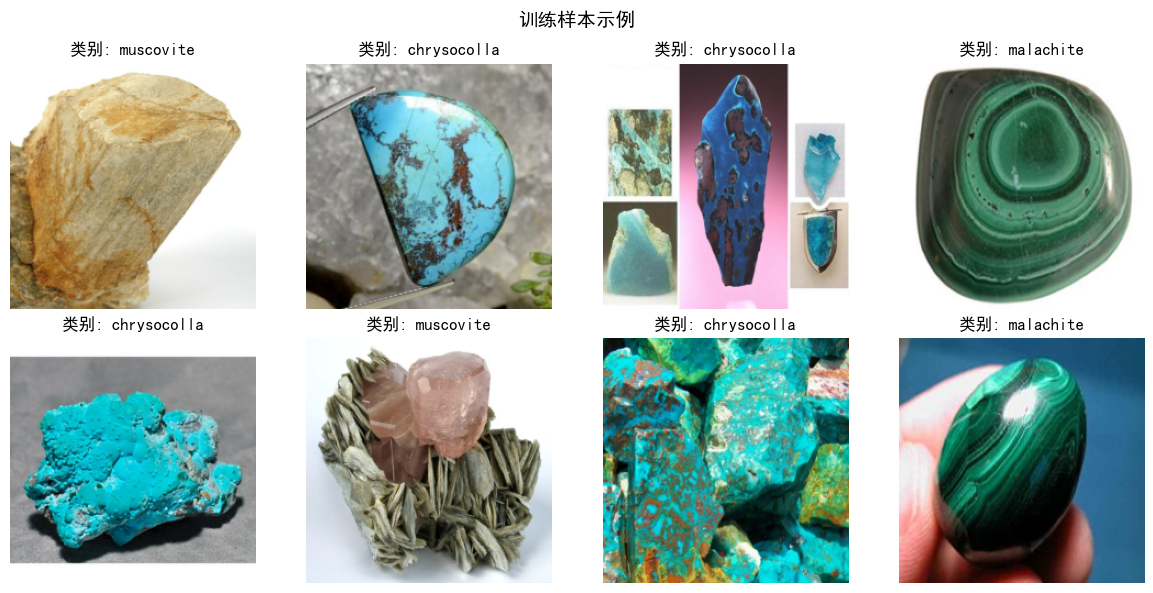

In [7]:
# ========== 第3步：加载数据集 ==========
print("\n第3步：加载数据集")
print("-" * 50)

# 加载数据集
dataset = datasets.ImageFolder(root=DATA_DIR, transform=transform_train)

# 划分训练集和验证集（80%训练，20%验证）
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# 注意：验证集需要使用不同的transform
# 重新设置验证集的transform
val_dataset.dataset.transform = transform_val

# 创建数据加载器
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"训练集大小: {len(train_dataset)}张 ({train_size/len(dataset)*100:.1f}%)")
print(f"验证集大小: {len(val_dataset)}张 ({val_size/len(dataset)*100:.1f}%)")
print(f"批次大小: {batch_size}")
print(f"训练批次数: {len(train_loader)}")
print(f"验证批次数: {len(val_loader)}")

# 显示一个批次的样本
def show_batch_samples(loader, classes, num_samples=8):
    """显示一个批次中的样本"""
    dataiter = iter(loader)
    images, labels = next(dataiter)
    
    # 反归一化
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    images = images * std + mean
    images = torch.clamp(images, 0, 1)
    
    # 显示样本
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    axes = axes.flatten()
    
    for i in range(min(num_samples, len(images))):
        img = images[i].numpy().transpose(1, 2, 0)
        axes[i].imshow(img)
        axes[i].set_title(f"类别: {classes[labels[i]]}")
        axes[i].axis('off')
    
    plt.suptitle("训练样本示例", fontsize=14)
    plt.tight_layout()
    plt.show()

print("\n显示训练样本示例:")
show_batch_samples(train_loader, classes)

In [8]:
# ========== 第4步：构建模型 ==========
print("\n第4步：构建模型")
print("-" * 50)

# 加载预训练的ResNet18模型
print("加载预训练的ResNet18模型...")
model = models.resnet18(pretrained=True)

# 冻结除最后两层外的所有层（可选，加快训练）
print("冻结除最后一层外的所有层...")
for param in model.parameters():
    param.requires_grad = False

# 解冻最后的全连接层
model.fc = nn.Linear(model.fc.in_features, len(classes))
model.fc.requires_grad = True

# 或者解冻最后两层
# for param in model.layer4.parameters():
#     param.requires_grad = True

print(f"模型架构:")
print(f"  - 基础模型: ResNet18")
print(f"  - 预训练权重: ImageNet")
print(f"  - 输出类别数: {len(classes)}")
print(f"  - 可训练参数数量: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")



第4步：构建模型
--------------------------------------------------
加载预训练的ResNet18模型...


C:\Users\1\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\1\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


冻结除最后一层外的所有层...
模型架构:
  - 基础模型: ResNet18
  - 预训练权重: ImageNet
  - 输出类别数: 7
  - 可训练参数数量: 3591


In [9]:
# ========== 第5步：定义损失函数和优化器 ==========
print("\n第5步：定义损失函数和优化器")
print("-" * 50)

# 损失函数
criterion = nn.CrossEntropyLoss()

# 优化器（只优化可训练的参数）
optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), 
                      lr=0.001, momentum=0.9, weight_decay=1e-4)

# 学习率调度器
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

print(f"损失函数: CrossEntropyLoss")
print(f"优化器: SGD (lr=0.001, momentum=0.9, weight_decay=1e-4)")
print(f"学习率调度: StepLR (step_size=5, gamma=0.1)")



第5步：定义损失函数和优化器
--------------------------------------------------
损失函数: CrossEntropyLoss
优化器: SGD (lr=0.001, momentum=0.9, weight_decay=1e-4)
学习率调度: StepLR (step_size=5, gamma=0.1)


In [10]:
# ========== 第6步：训练模型 ==========
print("\n第6步：训练模型")
print("-" * 50)

# 设备配置
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
print(f"使用设备: {device}")

# 训练参数
epochs = 10
train_losses = []
val_losses = []
val_accuracies = []

print(f"开始训练，共 {epochs} 个epoch...")
print()

for epoch in range(epochs):
    # 训练阶段
    model.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for batch_idx, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        
        # 清零梯度
        optimizer.zero_grad()
        
        # 前向传播
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # 反向传播和优化
        loss.backward()
        optimizer.step()
        
        # 统计
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
        
        # 打印批次信息（每10个批次）
        if batch_idx % 10 == 0 and batch_idx > 0:
            print(f"  Epoch {epoch+1}/{epochs}, Batch {batch_idx}/{len(train_loader)}, Loss: {loss.item():.4f}")
    
    # 计算训练损失和准确率
    train_loss = running_loss / len(train_dataset)
    train_accuracy = 100 * train_correct / train_total
    train_losses.append(train_loss)
    
    # 验证阶段
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            
            # 计算准确率
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            # 保存预测和标签用于混淆矩阵
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # 计算验证损失和准确率
    val_loss = val_loss / len(val_dataset)
    val_accuracy = 100 * correct / total
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)
    
    # 更新学习率
    scheduler.step()
    
    # 打印epoch结果
    print(f"\n📊 Epoch {epoch+1}/{epochs}")
    print(f"  训练损失: {train_loss:.4f}, 训练准确率: {train_accuracy:.2f}%")
    print(f"  验证损失: {val_loss:.4f}, 验证准确率: {val_accuracy:.2f}%")
    print(f"  学习率: {optimizer.param_groups[0]['lr']:.6f}")
    print("-" * 60)

print("\n✅ 训练完成！")
print(f"🎯 最终验证准确率: {val_accuracy:.2f}%")



第6步：训练模型
--------------------------------------------------
使用设备: cuda
开始训练，共 10 个epoch...

  Epoch 1/10, Batch 10/24, Loss: 1.7668
  Epoch 1/10, Batch 20/24, Loss: 1.5793

📊 Epoch 1/10
  训练损失: 1.8582, 训练准确率: 28.66%
  验证损失: 1.5367, 验证准确率: 50.52%
  学习率: 0.001000
------------------------------------------------------------
  Epoch 2/10, Batch 10/24, Loss: 1.5082
  Epoch 2/10, Batch 20/24, Loss: 1.2902

📊 Epoch 2/10
  训练损失: 1.3734, 训练准确率: 53.40%
  验证损失: 1.1657, 验证准确率: 63.02%
  学习率: 0.001000
------------------------------------------------------------
  Epoch 3/10, Batch 10/24, Loss: 0.8633
  Epoch 3/10, Batch 20/24, Loss: 0.9402

📊 Epoch 3/10
  训练损失: 1.0431, 训练准确率: 66.36%
  验证损失: 0.9374, 验证准确率: 67.71%
  学习率: 0.001000
------------------------------------------------------------
  Epoch 4/10, Batch 10/24, Loss: 0.8469
  Epoch 4/10, Batch 20/24, Loss: 0.8537

📊 Epoch 4/10
  训练损失: 0.9071, 训练准确率: 73.04%
  验证损失: 0.8115, 验证准确率: 73.44%
  学习率: 0.001000
--------------------------------------------


第7步：训练过程可视化
--------------------------------------------------


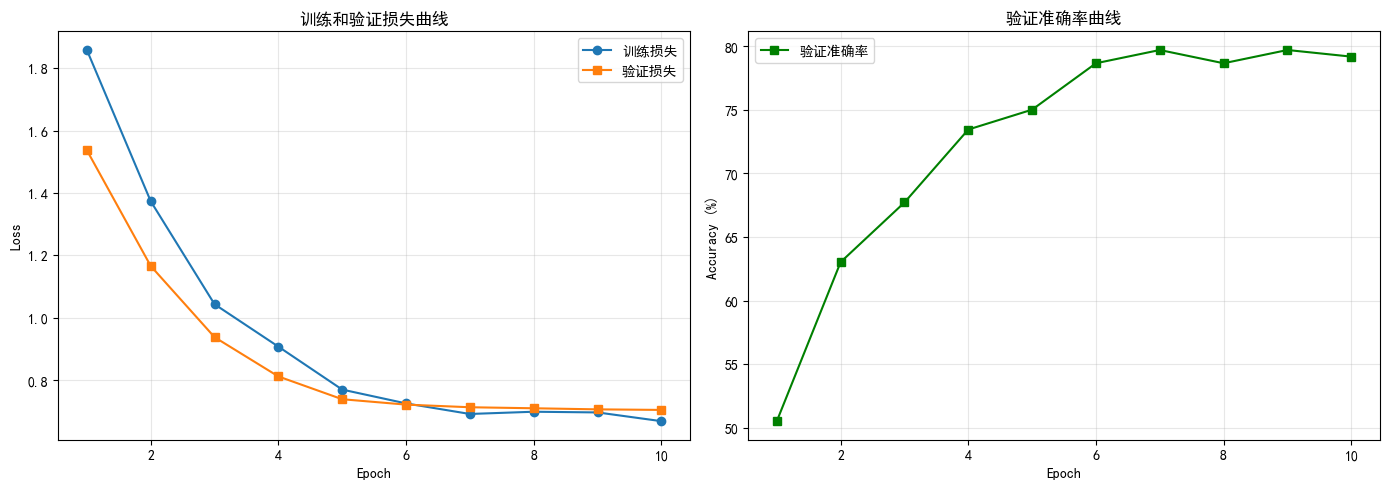

In [11]:
# ========== 第7步：可视化训练过程 ==========
print("\n第7步：训练过程可视化")
print("-" * 50)

# 绘制训练曲线
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 损失曲线
axes[0].plot(range(1, epochs+1), train_losses, label='训练损失', marker='o')
axes[0].plot(range(1, epochs+1), val_losses, label='验证损失', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('训练和验证损失曲线')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 准确率曲线
axes[1].plot(range(1, epochs+1), val_accuracies, label='验证准确率', marker='s', color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('验证准确率曲线')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


第8步：混淆矩阵和分类报告
--------------------------------------------------


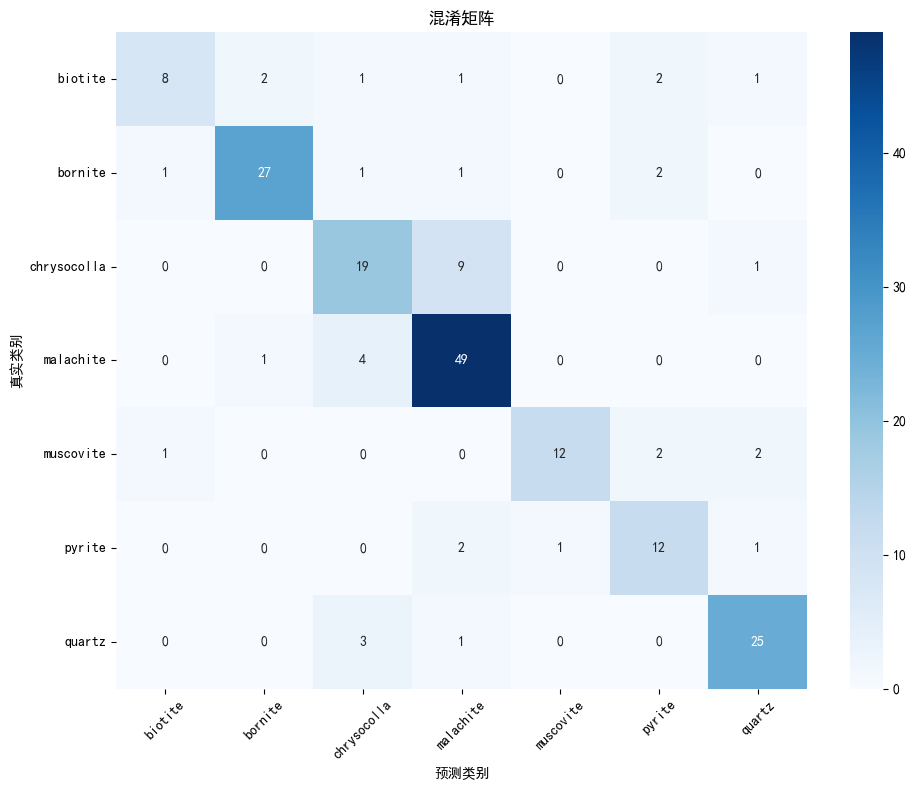


分类报告:
              precision    recall  f1-score   support

     biotite       0.80      0.53      0.64        15
     bornite       0.90      0.84      0.87        32
 chrysocolla       0.68      0.66      0.67        29
   malachite       0.78      0.91      0.84        54
   muscovite       0.92      0.71      0.80        17
      pyrite       0.67      0.75      0.71        16
      quartz       0.83      0.86      0.85        29

    accuracy                           0.79       192
   macro avg       0.80      0.75      0.77       192
weighted avg       0.80      0.79      0.79       192



In [12]:
# ========== 第8步：混淆矩阵和分类报告 ==========
print("\n第8步：混淆矩阵和分类报告")
print("-" * 50)

# 计算混淆矩阵
cm = confusion_matrix(all_labels, all_preds)

# 绘制混淆矩阵
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)
plt.xlabel('预测类别')
plt.ylabel('真实类别')
plt.title('混淆矩阵')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 打印分类报告
print("\n分类报告:")
print(classification_report(all_labels, all_preds, target_names=classes))

In [13]:
# 保存模型
model_save_path = 'baseline_resnet18.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'val_accuracy': val_accuracy,
    'classes': classes
}, model_save_path)

print(f"✅ 模型已保存到: {model_save_path}")
print(f"   模型详情:")
print(f"   - 准确率: {val_accuracy:.2f}%")
print(f"   - 训练轮数: {epochs}")
print(f"   - 类别数: {len(classes)}")

# ========== 第10步：总结 ==========
print("\n" + "="*60)
print("=== 基准模型训练总结 ===")
print("="*60)

✅ 模型已保存到: baseline_resnet18.pth
   模型详情:
   - 准确率: 79.17%
   - 训练轮数: 10
   - 类别数: 7

=== 基准模型训练总结 ===
